<a href="https://colab.research.google.com/github/oliveirangel/projetos_pandas-python/blob/main/Analise_Incendios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import seaborn as  sns
import matplotlib.pyplot as plt

In [ ]:
df_incendio = pd.read_csv('Dados Incendio.csv', encoding= 'latin1')
df_incendio.head()

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


In [ ]:
df_incendio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    6454 non-null   int64  
 1   state   6454 non-null   object 
 2   month   6454 non-null   object 
 3   number  6454 non-null   float64
 4   date    6454 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 252.2+ KB


In [ ]:
df_incendio.shape

(6454, 5)

In [ ]:
df_incendio.isnull().sum()

,0
year,0
state,0
month,0
number,0
date,0


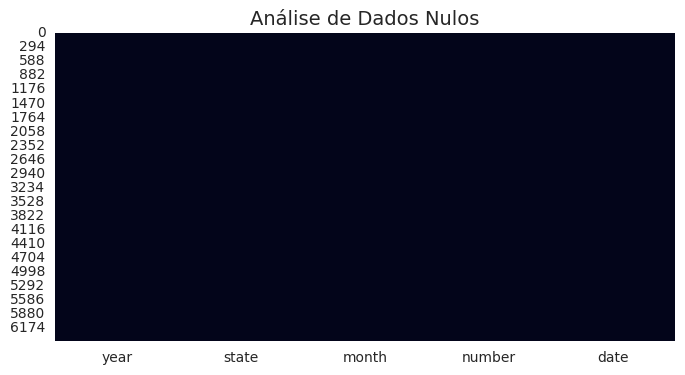

In [ ]:
# Gráfico Heatmap
plt.figure(figsize=(8,4))
plt.title('Análise de Dados Nulos', fontsize = 14)
sns.heatmap(df_incendio.isnull(), cbar= False);

In [ ]:
df_incendio.describe()

,year,number
count,6454.000000,6454.000000
mean,2007.461729,108.293163
std,5.746654,190.812242
min,1998.000000,0.000000
25%,2002.000000,3.000000
50%,2007.000000,24.000000
75%,2012.000000,113.000000
max,2017.000000,998.000000


In [ ]:
df_incendio['year'].unique()

array([1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008,
       2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017])

In [ ]:
df_incendio.columns

Index(['year', 'state', 'month', 'number', 'date'], dtype='object')

In [ ]:
df_incendio.rename(columns={
    'year':'Ano',
    'state':'Estado',
    'month':'Mês',
    'number':'Número',
    'date':'Data'
},inplace=True)

df_incendio.head()

,Ano,Estado,Mês,Número,Data
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


In [ ]:
# Somar a coluna 'Número', agrupada por 'Ano'.
Analise_Anual = df_incendio.groupby(by=['Ano'])['Número'].sum().reset_index()

Analise_Anual.head(10)


,Ano,Número
0,1998,20013.971
1,1999,26882.821
2,2000,27351.251
3,2001,29071.612
4,2002,37390.600
5,2003,42760.674
6,2004,38453.163
7,2005,35004.965
8,2006,33832.161
9,2007,33037.413


- **estimator** - Controla como a variável Y é agregada para cada valor de X. Por padrão, ele calcula a média. Mas nesse caso, cada 'Ano' ele irá somar todos os valores de 'Número.
- **alpha** - Controla a transparencia da linha. Pode receber um valor entre 0 e 1.
- **lw** - Largura da linha
- **fontweight= 'bold'** - negrito
- **plt.style.use()** - define o estilo do gráfico.
Ex: plt.style.use('bmh')

Text(0, 0.5, 'Quantidade')

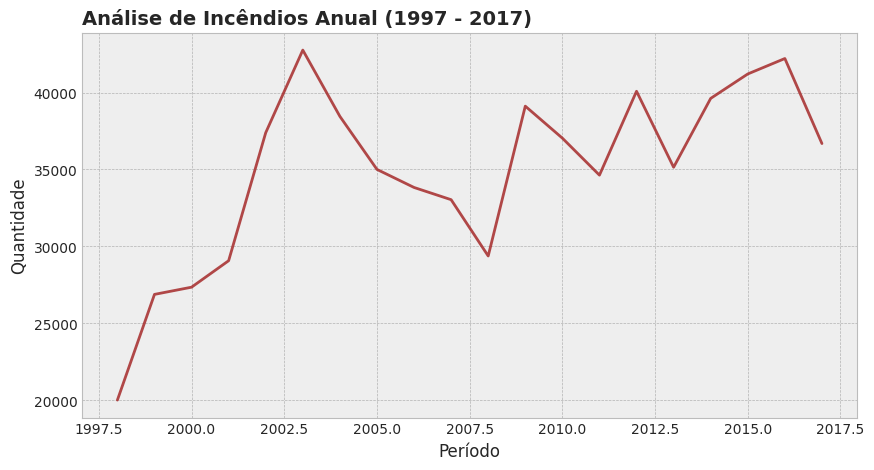

In [ ]:
# Gráfico Lineplot

plt.style.use('bmh')
plt.figure(figsize=(10,5))
sns.lineplot(data=Analise_Anual, x= 'Ano', y= 'Número', estimator= 'sum', lw= 2, color= '#A52A2A', alpha= 0.85)
plt.title('Análise de Incêndios Anual (1997 - 2017)', fontsize = 14, fontweight='bold', loc = 'left')
plt.xlabel('Período')
plt.ylabel('Quantidade')

In [ ]:
#Analise_02 = df_incendio[df_incendio['Ano'] == 2017].groupby(by=['Mês'])['Número'].sum().reset_index()
Analise_02 = df_incendio.groupby(by=['Ano', 'Mês'])['Número'].sum().reset_index()

Analise_02

,Ano,Mês,Número
0,1998,Abril,0.000
1,1998,Agosto,3964.616
2,1998,Dezembro,2043.407
3,1998,Fevereiro,0.000
4,1998,Janeiro,0.000
...,...,...,...
234,2017,Maio,2506.000
235,2017,Março,2017.000
236,2017,Novembro,6217.379
237,2017,Outubro,3600.159


- **palette= ' '**  paleta de cores
- **saturation=**  saturação
- **linewidth =**  tamanho da linha
- **width=**  tamanho da imagem


/tmp/ipykernel_5970/862925122.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




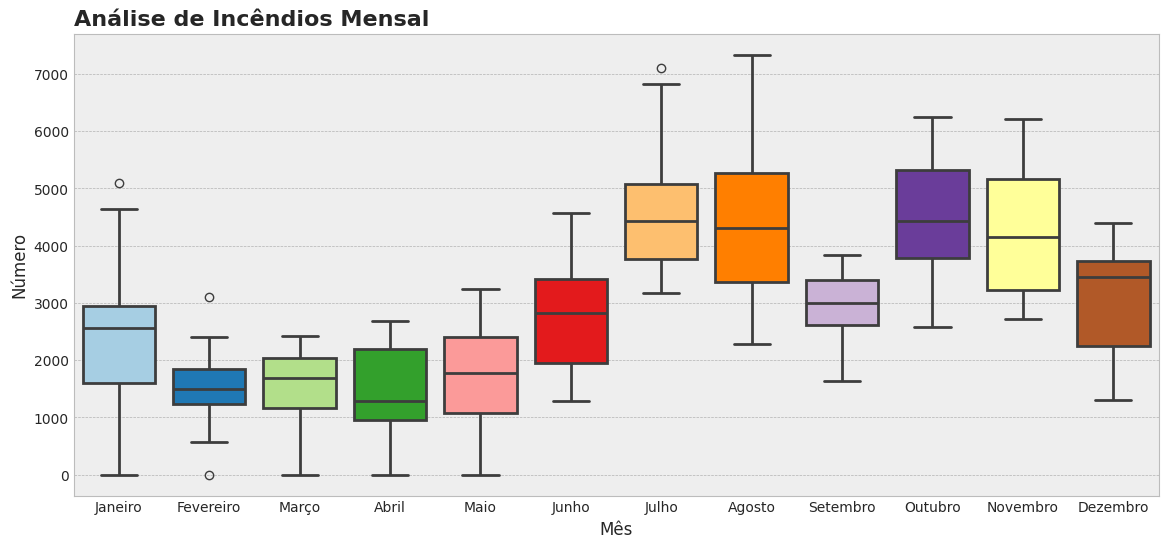

In [ ]:
# Gráfico Boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=Analise_02, x='Mês', y='Número', palette= 'Paired', saturation= 1, linewidth= 2, width= 0.8,
            order= ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'])
plt.title('Análise de Incêndios Mensal', fontsize = 16, fontweight='bold', loc = 'left')
plt.show()

In [ ]:
Analise_03 = df_incendio.groupby(by=['Estado'])['Número'].sum().reset_index().sort_values(by='Número', ascending=False)

Analise_03

,Estado,Número
10,Mato Grosso,96246.028
12,Paraiba,52435.918
20,Sao Paulo,51121.198
16,Rio,45160.865
4,Bahia,44746.226
15,Piau,37803.747
8,Goias,37695.520
11,Minas Gerais,37475.258
22,Tocantins,33707.885
3,Amazonas,30650.129


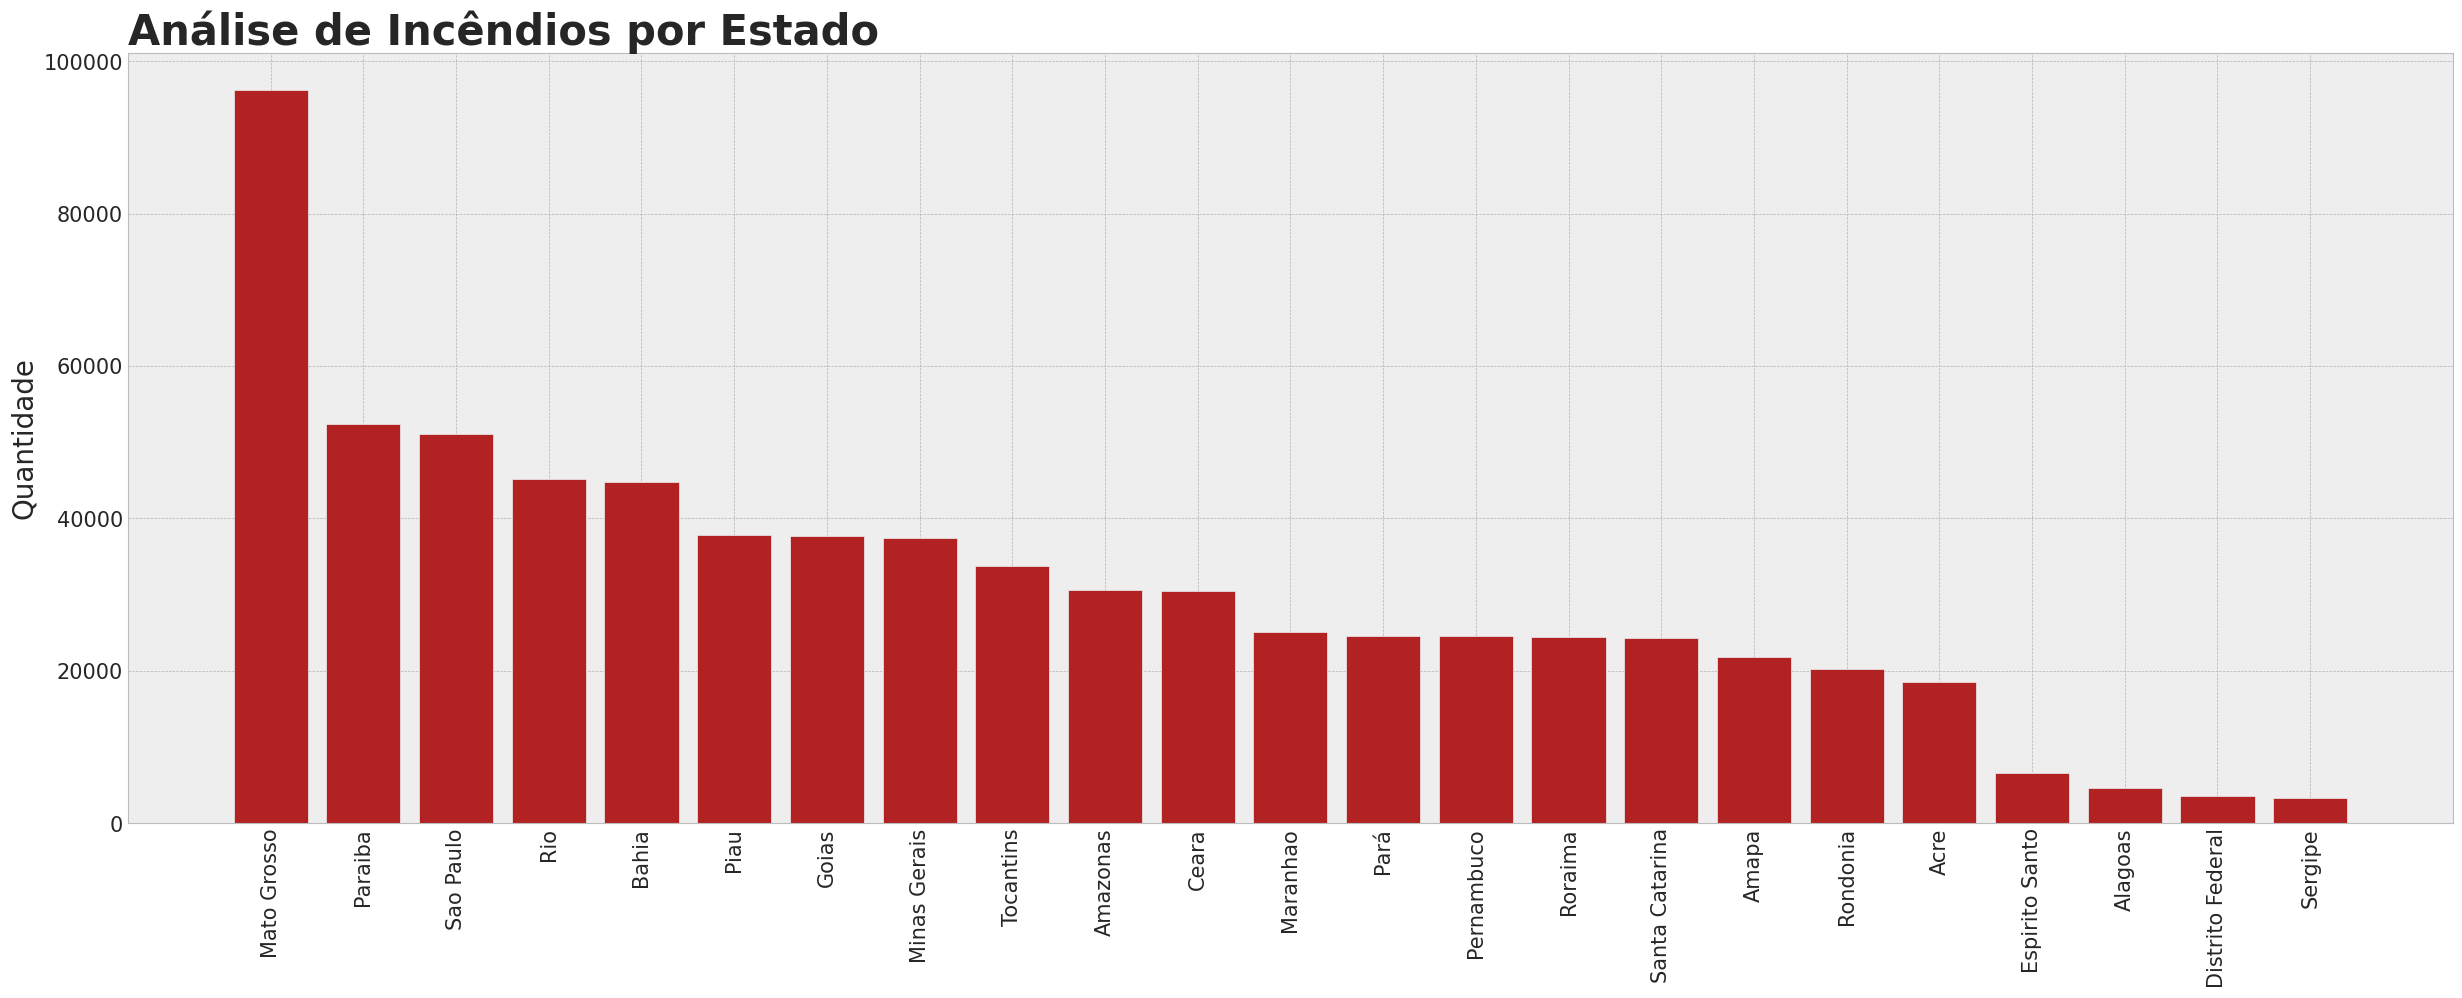

In [ ]:
# Gráfico Bar (barras)

plt.figure(figsize=(30,10))
plt.bar(Analise_03.Estado, Analise_03['Número'], color= '#B22222') # Pode chamar a coluna dos dois jeitos, com . e []
plt.title('Análise de Incêndios por Estado', fontsize = 30, fontweight='bold', loc = 'left')

plt.ylabel('Quantidade', fontsize=20)
plt.xticks(rotation= 90, fontsize=15) # Muda a posição dos valores de x e aumenta o tamanho da fonte
plt.yticks(fontsize=15);

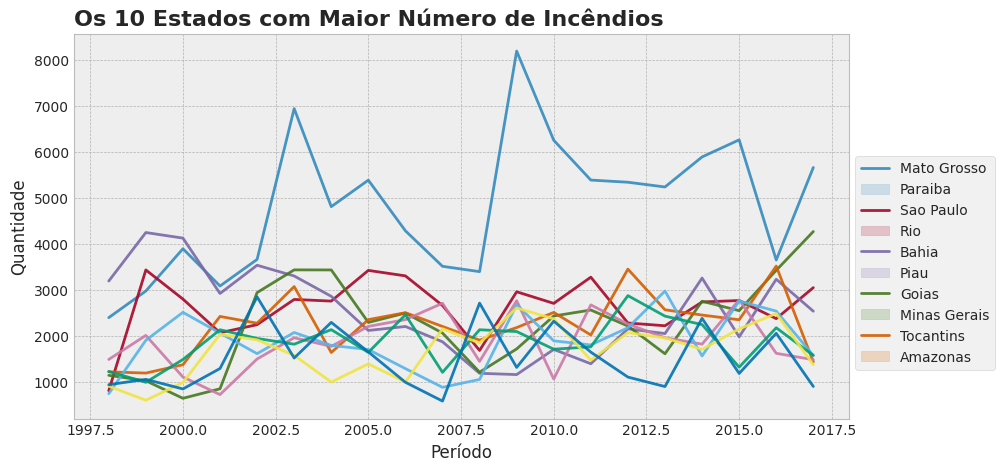

In [ ]:
Top10 = Analise_03['Estado'][0:10].values

plt.figure(figsize=(10,5))
plt.title('Os 10 Estados com Maior Número de Incêndios', fontsize= 16, fontweight= 'bold', loc= 'left')

for Coluna in Top10:

# Filtra o estado
    Filtro = df_incendio.loc[df_incendio['Estado'] == Coluna ]

# Agrupa os valores
    Analise_Estado = Filtro.groupby(by=['Ano'])['Número'].sum().reset_index()

# Gráfico
    sns.lineplot(data= Analise_Estado, x= 'Ano', y= 'Número', lw = 2, alpha = 0.9)

    plt.xlabel('Período', fontsize= 12 )
    plt.ylabel('Quantidade', fontsize= 12)

# Legenda
    plt.legend(Top10, bbox_to_anchor = (1, 0.7)); # Caixa de legenda centralizada (1), mas em outra posição (0.7)



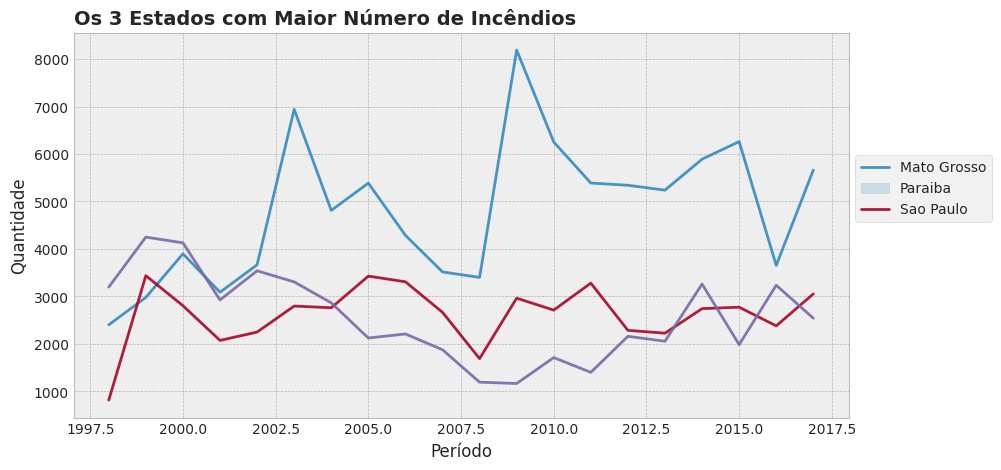

In [ ]:
Top3 = Analise_03['Estado'][0:3].values

plt.figure(figsize=(10,5))
plt.title('Os 3 Estados com Maior Número de Incêndios', fontsize= 14, fontweight= 'bold', loc= 'left')

for Coluna in Top3:

# Filtra o estado
    Filtro = df_incendio.loc[df_incendio['Estado'] == Coluna ]

# Agrupa os valores
    Analise_Estado = Filtro.groupby(by=['Ano'])['Número'].sum().reset_index()

# Gráfico
    sns.lineplot(data= Analise_Estado, x= 'Ano', y= 'Número', lw = 2, alpha = 0.9)

    plt.xlabel('Período', fontsize= 12 )
    plt.ylabel('Quantidade', fontsize= 12)

# Legenda
    plt.legend(Top3, bbox_to_anchor = (1, 0.7)); # Caixa de legenda centralizada (1), mas em outra posição (0.7)

## Análise Geográfica

In [ ]:
# Gerando um array dos estados
Estados = Analise_03.sort_values('Estado')['Estado'].values

# Gerando um array dos valores
Valores = Analise_03.sort_values('Estado')['Número'].values

Lat = [ -8.77, -9.71,	1.41, -3.07,	-12.96, -3.71, -15.83, -19.19, -16.64, -2.55,	-12.64,
       -18.10, -7.06, -5.53, -8.28, -8.28,	-22.84,	-11.22,	1.89,	-27.33,	-23.55,	-10.90,	-10.25 ]

Log = [ -70.55,	-35.73,	-51.77,	-61.66,	-38.51,	-38.54,	-47.86,	-40.34,	-49.31,	-44.30,	-55.42,	-44.38,
       -35.55,	-52.29,	-35.07,	-43.68,	-43.15,	-62.80,	-61.22,	-49.44,	-46.64,	-37.07,	-48.25 ]

# Relacionando os dados
Dicionario = {
    'Estados' : Estados,
    'Latitude' : Lat,
    'Longitude' : Log,
    'Incêndios' : Valores
}

# Criando um novo df
Analise_Geografica = pd.DataFrame ( Dicionario )

Analise_Geografica.head(10)

,Estados,Latitude,Longitude,Incêndios
0,Acre,-8.77,-70.55,18464.030
1,Alagoas,-9.71,-35.73,4644.000
2,Amapa,1.41,-51.77,21831.576
3,Amazonas,-3.07,-61.66,30650.129
4,Bahia,-12.96,-38.51,44746.226
5,Ceara,-3.71,-38.54,30428.063
6,Distrito Federal,-15.83,-47.86,3561.000
7,Espirito Santo,-19.19,-40.34,6546.000
8,Goias,-16.64,-49.31,37695.520
9,Maranhao,-2.55,-44.30,25129.131


In [ ]:
import plotly.express as px

px.density_mapbox(
    Analise_Geografica,
    lat = 'Latitude', # Colunas (lat,lon)
    lon = 'Longitude',
    z= 'Incêndios', # Valores
    radius= 30, # Raio, controla o quão espalhada ou focada a cor e o sombreamento do mapa será em torno de cada localização
    center=dict(lat=-12.700, lon=-46.5555), # Define qual ponto do mapa que será analisado, no caso será o Brasil
    zoom= 3,
    mapbox_style= 'open-street-map' # Estilo do mapa
)

### **Fontweight** - o valor pode ser numérico (varia de 100 a 900) ou string, sendo string:

- 'normal' (equivale a 400)
- 'bold' (equivale a 700)
- 'light' (equivale a 300)
- 'heavy' ou 'black' (equivale a 900)

**plt.subplot2grid()** - Esta é a função que permite criar subplots em um layout de grade mais personalizado, em comparação com plt.subplot() que é mais simples.



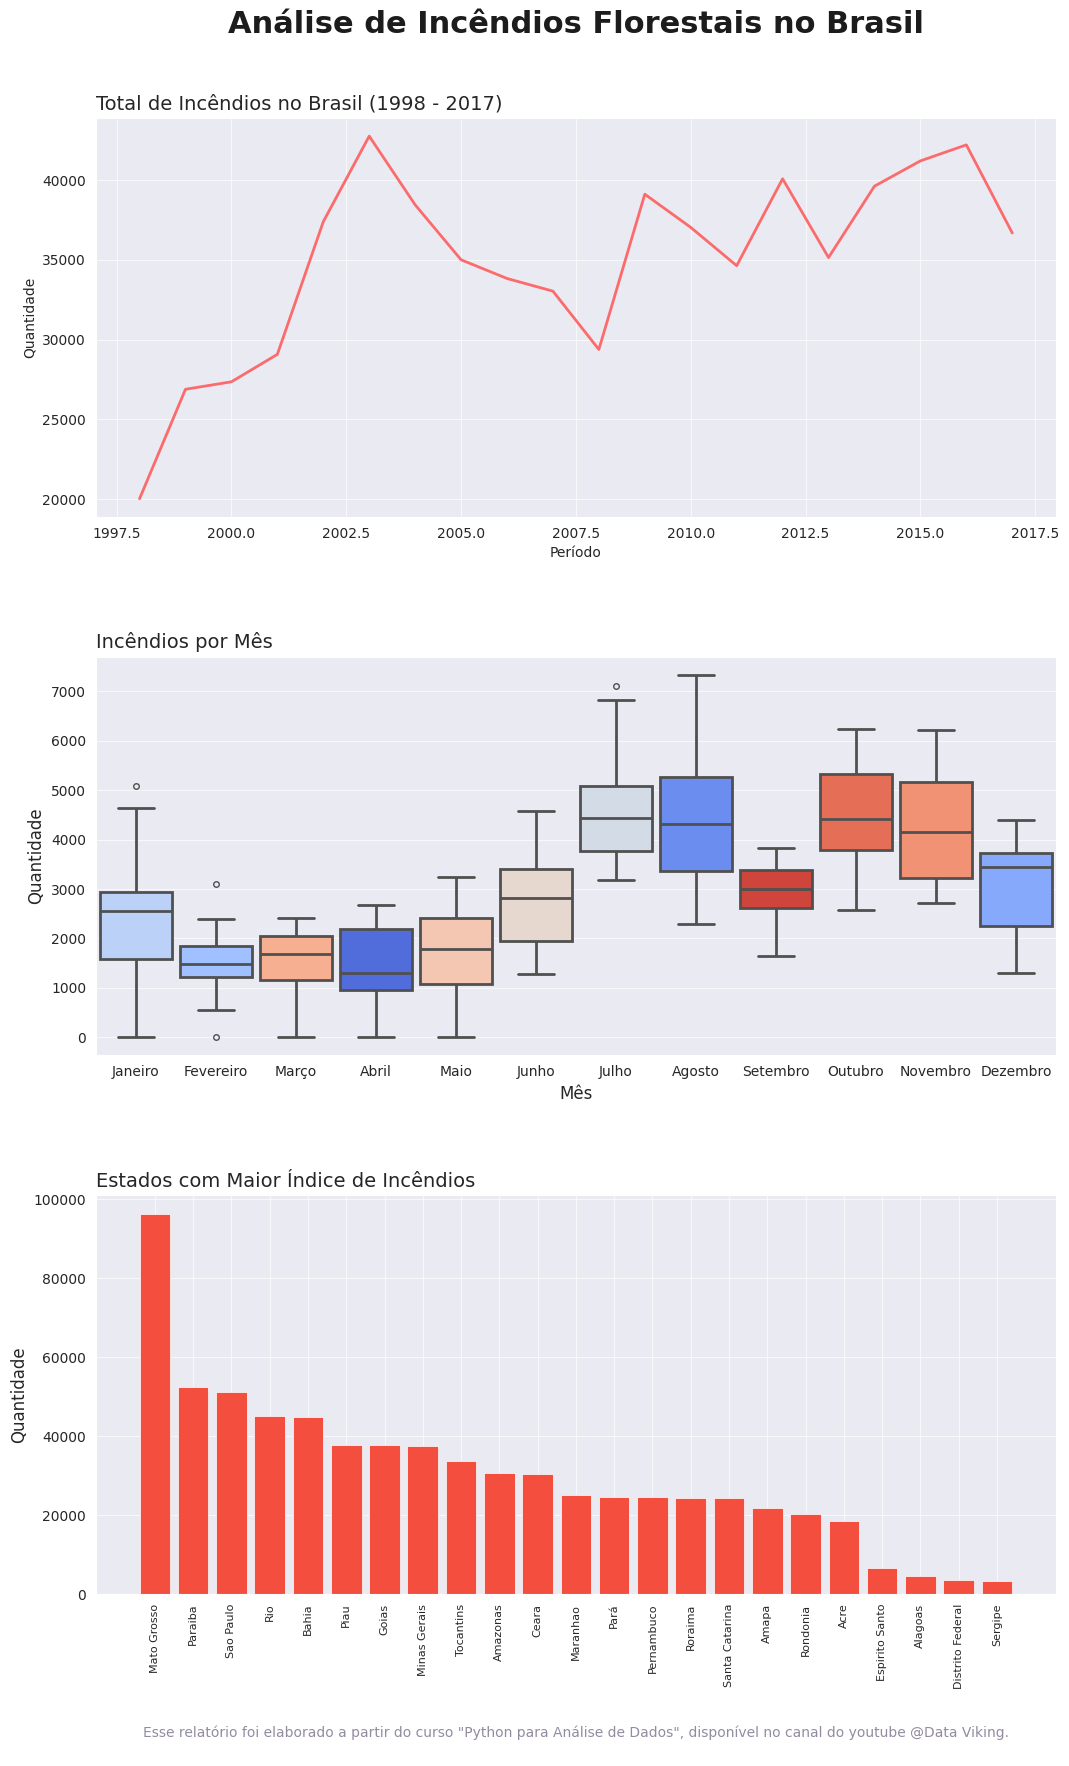

In [ ]:
import matplotlib.image as mpimg

sns.set_style('darkgrid') # Aplica o estilo 'darkgrid' globalmente

fig = plt.figure(figsize=(12, 18)) # Inicializa a figura com tamanho ajustado para 3 plots verticais

ax = [ None for _ in range(3) ] # Lista para armazenar os eixos de cada subplot (agora são apenas 3)

# Primeiro plot em um grade (3,1) - 3 linhas e 1 coluna, posicionado (0,0) - na primeira linha e primeira coluna
ax[0] = plt.subplot2grid((3,1), (0,0))

plt.title('Total de Incêndios no Brasil (1998 - 2017)', loc='left', fontsize=14 )
sns.lineplot( x='Ano', y='Número', data= Analise_Anual, color='#FF5555', lw=2, err_style=None , alpha=0.85)

plt.xlabel('Período', fontsize=10)
plt.ylabel('Quantidade', fontsize=10);

# Segundo plot em um grade (3,1) - 3 linhas e 1 coluna, posicionado (1,0) - na segunda linha e primeira coluna
ax[1] = plt.subplot2grid((3,1), (1,0))

plt.title('Incêndios por Mês', loc='left', fontsize=14 )
sns.boxplot(x='Mês', y='Número', data= Analise_02, palette="coolwarm", saturation=1, width=0.9, fliersize=4, linewidth=2,
            order=['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'],
            hue='Mês', legend=False)

plt.xlabel('Mês')
plt.ylabel('Quantidade');

# Terceiro plot em um grade (3,1) - 3 linhas e 1 coluna, posicionado (2,0) - na terceira linha e primeira coluna
ax[2] = plt.subplot2grid((3,1), (2,0))

plt.title('Estados com Maior Índice de Incêndios', loc='left', fontsize=14 )
plt.bar( Analise_03['Estado'], Analise_03['Número'], color='#f44e3f' )

plt.ylabel('Quantidade')
plt.xticks( rotation=90, fontsize=8 );


fig.tight_layout()

# Incluindo título na figura
plt.suptitle(f'Análise de Incêndios Florestais no Brasil', fontsize=22, color='#1C1C1C', fontweight= 'bold' )
plt.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.92, wspace=0.35, hspace=0.35)

# Rodapé
Rodape = '''
Esse relatório foi elaborado a partir do curso "Python para Análise de Dados", disponível no canal do youtube @Data Viking.
'''

# Incluindo o rodapé no relatório
fig.text( 0.5, 0.01, Rodape, ha='center', va='bottom', size=10, color='#938ca1');

plt.show()